In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Loading

In [4]:
def reduce_mem_usage(df):
    """Reduce dataframe memory usage"""
    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.float32)

    return df
def weighted_rmse_score(y_target, y_pred, w):
    """Competition metric"""
    y_target = np.array(y_target, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)
    w = np.array(w, dtype=np.float64)
    
    denom = np.sum(w * y_target ** 2)
    if denom == 0 or np.isnan(denom):
        return 0.0
    
    numerator = np.sum(w * (y_target - y_pred) ** 2)
    ratio = numerator / denom
    clipped = np.clip(ratio, 0.0, 1.0)
    score = np.sqrt(1.0 - clipped)
    
    return float(score)

In [5]:
train_df= reduce_mem_usage(pd.read_parquet('train.parquet'))
test_df = reduce_mem_usage(pd.read_parquet('test.parquet'))

In [6]:
print(f"Unique codes: {train_df['code'].nunique()}")
print(f"Unique sub_codes: {train_df['sub_code'].nunique()}")
print(f"Unique sub_categories: {train_df['sub_category'].nunique()}")
print(f"Unique horizons: {train_df['horizon'].nunique()}")
print(f"Value count of codes: \n{train_df['code'].value_counts()}")
print(f"Value count of sub_categories: \n{train_df['sub_category'].value_counts()}")
print(f"Value count of horizons:  \n{train_df['horizon'].value_counts()}")

Unique codes: 23
Unique sub_codes: 180
Unique sub_categories: 5
Unique horizons: 4
Value count of codes: 
code
OSJL3A7Y    564790
6LB028J8    484082
K7Y1TTAH    324479
VFWIFJPS    318517
W2MW3G2L    305116
1HEMHZK2    293024
660DZME0    264071
4KUR2ZOZ    263685
SJZP0OVU    237283
84J8BJFZ    234375
MRV5UON2    223256
K8I5QG74    222146
EP12UF2K    213164
X9BZ68VQ    209261
W4S29LF4    193977
MLAAMU3K    184735
2RBMUWP1    176409
10BAVIDU    134886
QAQDDTPJ    130876
83EG83KQ    118694
HYOGKLEV     92259
WH61ASEA     74291
CXEQN6KB     74038
Name: count, dtype: int64
Value count of sub_categories: 
sub_category
PZ9S1Z4V    1074239
DPPUO5X2    1072705
NQ58FVQM    1067164
PHHHVYZI    1067164
V8BKY1IV    1056142
Name: count, dtype: int64
Value count of horizons:  
horizon
1     1394653
3     1385816
10    1337236
25    1219709
Name: count, dtype: int64


Columns with missing values (%):
feature_at    12.471882
feature_by    11.019194
feature_ay     8.541964
feature_cd     7.496402
feature_ce     5.167840
feature_cf     4.428905
feature_al     4.223319
feature_aw     3.844446
feature_bz     2.842613
feature_bi     2.762237
dtype: float64


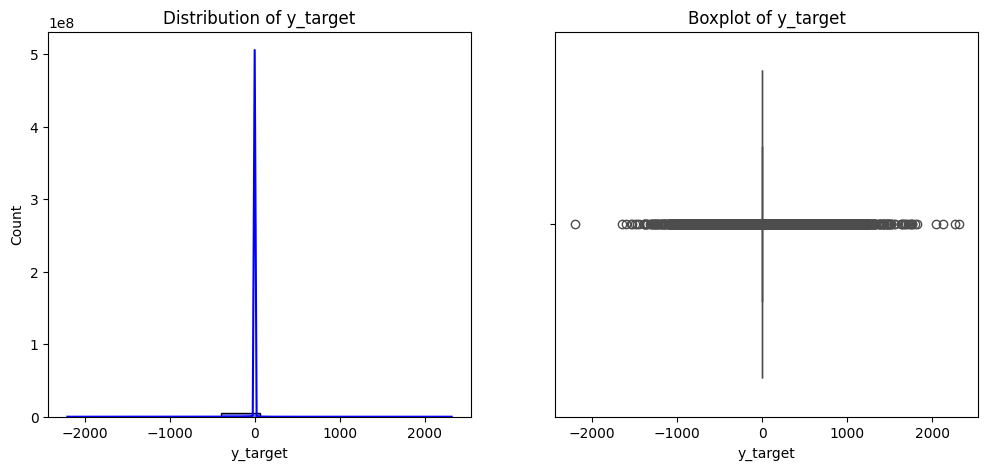


Target Statistics:
count    5.337414e+06
mean    -6.659051e-01
std      3.252764e+01
min     -2.201882e+03
25%     -1.290776e-01
50%     -5.774818e-04
75%      5.106807e-02
max      2.314411e+03
Name: y_target, dtype: float64

Time Series Range:
Train ts_index: 1 to 3601
Test ts_index: 3602 to 4376


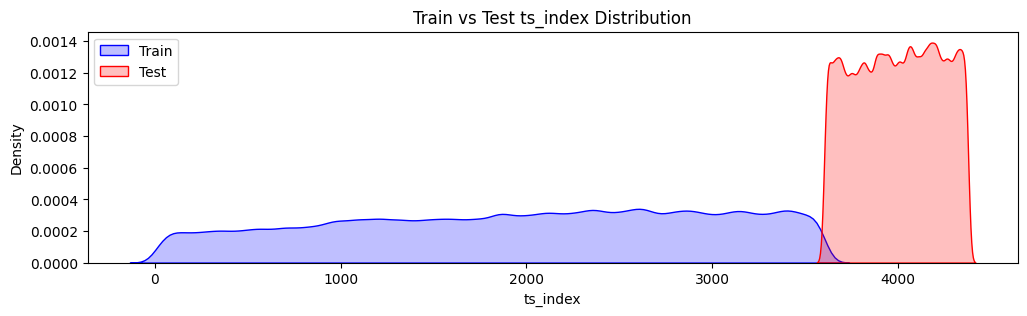

In [7]:
# 1. Missing Value Analysis
# Calculate the percentage of missing values per columns
missing_props = train_df.isnull().sum() / len(train_df) * 100
missing_props = missing_props[missing_props > 0].sort_values(ascending=False)

print("Columns with missing values (%):")
print(missing_props.head(10)) # Show top 10 missing columns


# 2. Target Distribution
plt.figure(figsize=(12, 5))

# Plot histogram of y_target
plt.subplot(1, 2, 1)
sns.histplot(train_df["y_target"], bins=10, kde=True, color="blue")
plt.title("Distribution of y_target")

# Plot boxplot to see outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=train_df['y_target'], color='orange')
plt.title('Boxplot of y_target')
plt.show()

# Print basic statistics of target
print("\nTarget Statistics:")
print(train_df['y_target'].describe())


# 3. Time Series Split Check
# Check min/max ts_index for train and test
print("\nTime Series Range:")
print(f"Train ts_index: {train_df['ts_index'].min()} to {train_df['ts_index'].max()}")
print(f"Test ts_index: {test_df['ts_index'].min()} to {test_df['ts_index'].max()}")

# Visualize the overlap (if any)
plt.figure(figsize=(12, 3))
sns.kdeplot(train_df['ts_index'], label='Train', fill=True, color='blue')
sns.kdeplot(test_df['ts_index'], label='Test', fill=True, color='red')
plt.title('Train vs Test ts_index Distribution')
plt.legend()
plt.show()

In [8]:
missing_props = train_df.isnull().sum() / len(train_df) * 100
missing_props = missing_props[missing_props > 0].sort_values(ascending=False)

In [9]:
missing_props.head(10)

feature_at    12.471882
feature_by    11.019194
feature_ay     8.541964
feature_cd     7.496402
feature_ce     5.167840
feature_cf     4.428905
feature_al     4.223319
feature_aw     3.844446
feature_bz     2.842613
feature_bi     2.762237
dtype: float64

In [10]:
# 1. CHECK IF DATA IS SORTED BY ts_index
is_sorted = train_df['ts_index'].is_monotonic_increasing
print(f"Data is sorted (ascending): {is_sorted}")

# For each code/group separately (if you have multiple series):
is_sorted_by_group = train_df.groupby(['code', 'sub_code'])['ts_index'].apply(
    lambda x: x.is_monotonic_increasing
).all()
print(f"Data is sorted within each code/sub_code group: {is_sorted_by_group}")

# 2. FIND GAPS IN TIME SERIES
gaps = train_df.groupby(['code', 'sub_code'])['ts_index'].apply(
    lambda x: x.diff().max()
)
print(f"Max gap in ts_index: {gaps.max()}")
print(f"Groups with gaps:\n{gaps[gaps > 1]}")

# 3. CHECK FOR DUPLICATES
duplicates = train_df.duplicated(subset=['code', 'sub_code', 'ts_index']).sum()
print(f"Duplicate (code, sub_code, ts_index) combinations: {duplicates}")

# 4. CHECK MISSING VALUES IN KEY COLUMNS
print(f"\nMissing values:")
print(train_df[['ts_index', 'code', 'sub_code', 'y_target']].isnull().sum())

# 5. READY FOR FFILL?
ready_for_ffill = (
    is_sorted_by_group and 
    duplicates == 0 and 
    train_df[['ts_index', 'code', 'sub_code']].isnull().sum().sum() == 0
)
print(f"\n✓ Data is ready for ffill: {ready_for_ffill}")

Data is sorted (ascending): False
Data is sorted within each code/sub_code group: False
Max gap in ts_index: 134.0
Groups with gaps:
code      sub_code
10BAVIDU  236HB58W     3.0
          2FDNH5AZ     2.0
          2S7LSUP9     2.0
          3US8M659     4.0
          5D1HYR3L     2.0
                      ... 
X9BZ68VQ  YLX4X4O9     2.0
          YNRPMTCD     2.0
          YP5Z0HWJ     2.0
          Z4D5MJL4    12.0
          ZT5R1WKA    12.0
Name: ts_index, Length: 1786, dtype: float32
Duplicate (code, sub_code, ts_index) combinations: 5051952

Missing values:
ts_index    0
code        0
sub_code    0
y_target    0
dtype: int64

✓ Data is ready for ffill: False


In [11]:
missing_cols = [col for col in train_df.columns if train_df[col].isnull().any() and col not in ['id', 'code', 'sub_code', 'sub_category']]
for col in missing_cols: 
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)
    # Use train median for test to avoid leakage
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna(median_val)

In [12]:
import sys
sys.path.append(r'c:\Users\as\OneDrive - ntpc.co.in\Desktop\Data Science\Kaggle Competitions')
from target_encoder import TargetEncoder

In [13]:
te = TargetEncoder(cols_to_encode=['code', 'sub_code', 'sub_category'],drop_original=True)

In [14]:
X_transformed = te.fit_transform(train_df, y=train_df['y_target'])

In [15]:
X_transformed.head()

,id,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,...,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight,TE_code_mean,TE_sub_code_mean,TE_sub_category_mean
0,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__89,25,89,29,16.364094,7.464023,5.966933,1.622184,10.261360,4.914369,...,-0.001568,-0.133697,2.849819,0.112068,1,-0.551324,40.982571,-0.023179,-0.126853,-1.224859
1,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__1__89,1,89,53,2.858806,5.050617,15.906651,10.879453,3.072151,4.091032,...,-0.001568,-0.133697,2.849819,0.112068,1,-0.315583,150.075409,-0.023548,-0.127064,-1.226493
2,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__3__89,3,89,51,9.585452,1.076268,9.004147,16.740490,15.166901,11.427982,...,-0.001568,-0.133697,2.849819,0.112068,1,-0.362894,115.953552,-0.023069,-0.126930,-1.206326
3,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__10__89,10,89,44,8.840588,15.034635,4.170780,1.584433,5.383461,3.099427,...,-0.001568,-0.133697,2.849819,0.112068,1,-0.667023,64.573074,-0.023179,-0.126853,-1.224859
4,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__90,25,90,28,2.303825,7.696209,12.896100,13.830051,0.552439,5.731490,...,-0.001568,-0.174660,2.738606,0.109204,1,-0.437398,41.948761,-0.023605,-0.130196,-1.235945


In [16]:
features = [col for col in X_transformed.columns if col not in ["id", "y_target", "weight"]]
target = "y_target"
print(f"\nNumber of features: {len(features)}")


Number of features: 91


<Axes: xlabel='ts_index', ylabel='Density'>

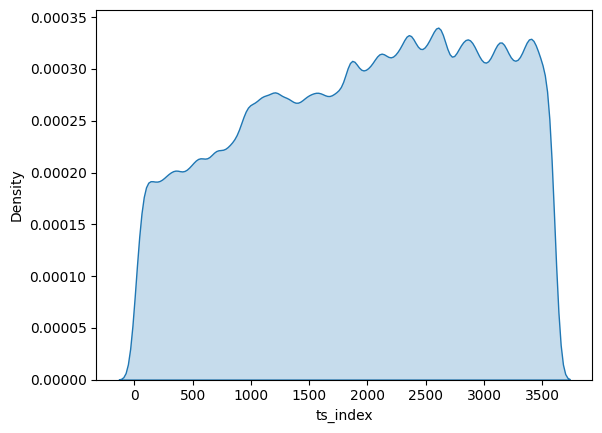

In [17]:
sns.kdeplot(X_transformed['ts_index'], fill=True)

In [18]:
percentile_80 = train_df['ts_index'].quantile(0.80)
print(f"80th percentile of ts_index: {percentile_80}")


80th percentile of ts_index: 2967.0


In [19]:
X_train = X_transformed[X_transformed['ts_index'] <= percentile_80][features]
y_train = X_transformed[X_transformed['ts_index'] <= percentile_80][target]
w_train = X_transformed[X_transformed['ts_index'] <= percentile_80]['weight']

X_val = X_transformed[X_transformed['ts_index'] > percentile_80][features]
y_val = X_transformed[X_transformed['ts_index'] > percentile_80][target]
w_val = X_transformed[X_transformed['ts_index'] > percentile_80]['weight']

In [20]:
print(f"Train set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")

Train set shape: (4271057, 91)
Validation set shape: (1066357, 91)


In [21]:
import lightgbm as lgb
import gc # Garbage collector for memory management

In [22]:
train_data = lgb.Dataset(X_train, label=y_train, weight=w_train)
val_data = lgb.Dataset(X_val, label=y_val, weight=w_val, reference=train_data)
params = {
    'objective': 'regression', # Predicting continuous values
    'metric': 'rmse',          # Root Mean Squared Error
    'boosting_type': 'gbdt',   # Gradient Boosting Decision Tree
    'learning_rate': 0.1,      # Step size
    'num_leaves': 31,          # Max leaves in a tree
    'feature_fraction': 0.8,   # Select 80% of features per iteration
    'bagging_fraction': 0.8,   # Select 80% of data per iteration
    'bagging_freq': 5,         # Perform bagging every 5 iterations
    'seed': 42,                # Random seed for reproducibility
    'verbosity': -1,           # Suppress warnings
    'n_jobs': -1               # Use all CPU cores
}
print("Training LightGBM model...")

# We use early_stopping to prevent overfitting if validation score stops improving
model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,           # Max number of trees
    valid_sets=[train_data, val_data], # Datasets to evaluate
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50), # Stop if no improvement for 50 rounds
        lgb.log_evaluation(period=50)           # Print progress every 50 rounds
    ]
)
print(f"Best iteration: {model.best_iteration}")
print(f"Best validation RMSE: {model.best_score['valid']['rmse']}")


# --- 4. Evaluate with Competition Metric ---
print("\nPredicting on validation set...")
y_pred_val = model.predict(X_val, num_iteration=model.best_iteration)

score = weighted_rmse_score(y_val, y_pred_val, w_val)
print(f"\n>>> VALIDATION SCORE (Weighted RMSE): {score:.5f}")

del train_data, val_data
gc.collect()

Training LightGBM model...
Training until validation scores don't improve for 50 rounds
[50]	train's rmse: 0.00197835	valid's rmse: 0.00274939
Early stopping, best iteration is:
[22]	train's rmse: 0.00201035	valid's rmse: 0.0027132
Best iteration: 22
Best validation RMSE: 0.002713196337574567

Predicting on validation set...

>>> VALIDATION SCORE (Weighted RMSE): 0.12694


9861

In [23]:
#prediction on test set
X_test = te.transform(test_df)
test_preds = model.predict(X_test[features], num_iteration=model.best_iteration)

c:\Users\as\OneDrive - ntpc.co.in\Desktop\Data Science\Kaggle Competitions\target_encoder.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
c:\Users\as\OneDrive - ntpc.co.in\Desktop\Data Science\Kaggle Competitions\target_encoder.py:75: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because

In [24]:
test_ids = test_df['id']

In [25]:
submission_df = pd.DataFrame({
    'id': test_ids,
    'prediction': test_preds
})

In [26]:
filename = 'submission_timeseries.csv'
submission_df.to_csv(filename, index=False)
